# **Example 10**: GSFit reconstructs ST40 from real data


In [1]:
from datetime import datetime

import gsfit_rs
import matplotlib.pyplot as plt
import mdsthin
import numpy as np
from gsfit import Gsfit
from gsfit import plotting as gsfit_plotting
from scipy.constants import mu_0
from scipy.interpolate import RectBivariateSpline
from st40_database import GetData

In [2]:
# Set the Matplotlib backend (inline=png; widget=interactive)
# %matplotlib inline
%matplotlib widget

In [3]:
pulse_num = 13_560
pulse_num_read = pulse_num
pulse_num_write = pulse_num + 52_000_000

In [4]:
with mdsthin.Connection("smaug") as conn:
    conn.openTree("TS", pulse_num)
    ts_r = conn.get("\\TS::TOP.BEST:R").data().astype(np.float64)
    ts_z = conn.get("\\TS::TOP.BEST:Z").data().astype(np.float64)

In [5]:
gsfit_controller_pressure_constrained = Gsfit(
    pulseNo=pulse_num,
    run_name="TEST024",
    run_description="Same as TEST022, but more times.",
    write_to_mds=True,
    pulseNo_write=pulse_num_write,
)
gsfit_controller_pressure_constrained.settings["GSFIT_code_settings.json"]["timeslices"]["method"] = "user_defined"
gsfit_controller_pressure_constrained.settings["GSFIT_code_settings.json"]["database_reader"]["st40_mdsplus"]["workflow"]["psu2coil"]["run_name"] = "RUN05"



2026-06-04 15:07:30  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "passive_dof_regularisation.json"
2026-06-04 15:07:30  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "sensor_weights_bp_probe.json"
2026-06-04 15:07:30  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "sensor_weights_dialoop.json"
2026-06-04 15:07:30  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "sensor_weights_flux_loops.json"
2026-06-04 15:07:30  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "sensor_weights_isoflux.json"
2026-06-04 15:07:30  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "sensor_weights_pressure.json"
2026-06-04 15:07:30  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "sensor_weights_rogowski_coils.json"
2026-06-04 15:07:3

In [ ]:
# Find good time slices using BAD_MA values in the PPTS tree
with mdsthin.Connection("smaug") as conn:
    conn.openTree("PPTS", pulse_num)
    ts_time_vector = conn.get("\\PPTS::TOP.BEST:TIME").data().astype(np.float64)
    ts_bad_ma_times = conn.get("\\PPTS::TOP.BEST.GLOBAL:BAD_MA").data().astype(bool)
    
for i, (time, bad_ma) in enumerate(zip(ts_time_vector, ts_bad_ma_times)):
    if bad_ma:
        print(f"\033[91m{i:02d} {time:6.3f} s\033[0m", end="  ")  # Red text for bad time slices
    else:
        print(f"\033[92m{i:02d} {time:6.3f} s\033[0m", end="  ")  # Green text for good time slices
    if (i + 1) % 10 == 0:
        print()

good_indices = np.where(~ts_bad_ma_times)[0]
print(f"\nGood time slice indices: {good_indices}")
# set good_indices to np.array([15, 16, 17, 18, 19, 20]) otherwise the code takes too long
good_indices = np.array([15, 16, 17, 18, 19, 20])

NameError: name 'mdsthin' is not defined

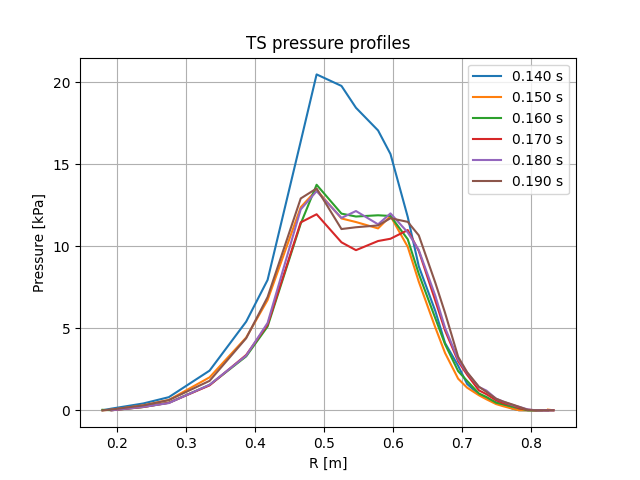

In [7]:
# Provide GSFit with the TS data as a constraint on the fit
with mdsthin.Connection("smaug") as conn:
    conn.openTree("TS", pulse_num)
    ts_r = conn.get("\\TS::TOP.BEST:R").data().astype(np.float64)
    ts_z = conn.get("\\TS::TOP.BEST:Z").data().astype(np.float64)
    ts_pe = conn.get("\\TS::TOP.BEST.PROFILES:PE").data().astype(np.float64)
    
# Plot the TS pressure vs ts_r for the selected pulses
plot_indices = np.array([15, 16, 17, 18, 19, 20])
# plot_indices = np.array([17])
fig, ax = plt.subplots()
ax.set_title("TS pressure profiles")
ax.grid()
for i in plot_indices:
    ts_pressure_profile = ts_pe[i, :]
    ax.plot(ts_r, ts_pressure_profile / 1e3, label=f"{ts_time_vector[i]:.3f} s")
ax.set_xlabel("R [m]")
ax.set_ylabel("Pressure [kPa]")
ax.legend()


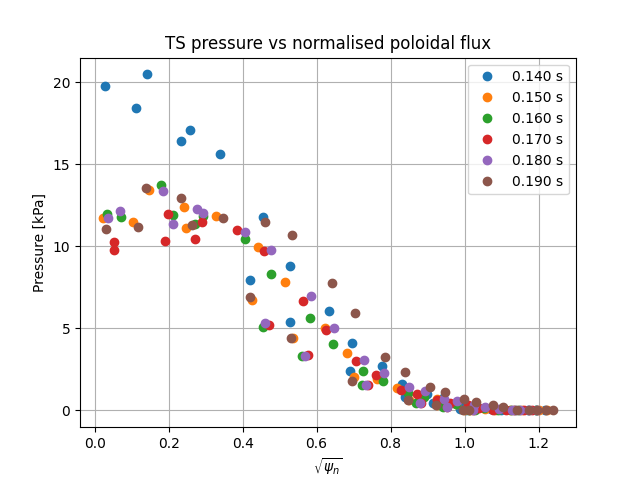

In [8]:
# Get # Psi R and Z from PPAC GSFit MDSPlus
with mdsthin.Connection("smaug") as conn:
    conn.openTree("GSFIT", pulse_num_read)
    gsfit_ppac_r = conn.get("\\GSFIT::TOP.BEST.TWO_D:RGRID").data().astype(np.float64)
    gsfit_ppac_z = conn.get("\\GSFIT::TOP.BEST.TWO_D:ZGRID").data().astype(np.float64)
    gsfit_ppac_psi = conn.get("\\GSFIT::TOP.BEST.TWO_D:PSI").data().astype(np.float64)
    gsfit_ppac_time = conn.get("\\GSFIT::TOP.BEST:TIME").data().astype(np.float64)
    gsfit_ppac_psi_a = conn.get("\\GSFIT::TOP.BEST.GLOBAL:PSI_A").data().astype(np.float64)
    gsfit_ppac_psi_b = conn.get("\\GSFIT::TOP.BEST.GLOBAL:PSI_B").data().astype(np.float64)
gsfit_ppac_psin = np.zeros_like(gsfit_ppac_psi)
for i, time in enumerate(gsfit_ppac_time):
    gsfit_ppac_psin[i, :, :] = (gsfit_ppac_psi_a[i] - gsfit_ppac_psi[i, :, :]) / (gsfit_ppac_psi_a[i] - gsfit_ppac_psi_b[i])

# Use rect bivariate spline to find the psin values of each TS sensor location
# Need nested for loop, first find nearest time slice in GSFit PPAC data, then find the psin value at each TS sensor location for that time slice
# PSI is stored as (n_time, n_z, n_r), so transpose to get (n_r, n_z) for RectBivariateSpline
ts_psin_values = np.zeros((len(ts_time_vector), len(ts_r)))
for i_time, time in enumerate(ts_time_vector):
    # Find nearest time slice in GSFit PPAC data
    time_differences = np.abs(gsfit_ppac_time - time)
    nearest_time_index = np.argmin(time_differences)

    spline = RectBivariateSpline(gsfit_ppac_r, gsfit_ppac_z, gsfit_ppac_psin[nearest_time_index, :, :].T)

    # Find psin values at each TS sensor location (grid=False evaluates at individual points, returning scalars)
    for i_ts in range(len(ts_r)):
        ts_psin_values[i_time, i_ts] = spline(ts_r[i_ts], ts_z[i_ts], grid=False)

fig, ax = plt.subplots()
ax.set_title("TS pressure vs normalised poloidal flux")
ax.grid()
for i_ts in plot_indices:
    ts_plot_time = ts_time_vector[i_ts]
    ax.plot(np.sqrt(ts_psin_values[i_ts, :]),
            ts_pe[i_ts, :] / 1e3,
            label=f"{ts_plot_time:.3f} s",
            linestyle="none",
            marker="o",)
ax.set_xlabel(r"$\sqrt{\psi_n}$")
ax.set_ylabel("Pressure [kPa]")
ax.legend()


In [9]:
pressure_sensors = gsfit_rs.Pressure()
ts_n = len(ts_r)
ts_good_times = ts_time_vector[good_indices]
for i_ts_sensor in range(ts_n):
    measured_pressure_full = 2 * ts_pe[good_indices, i_ts_sensor]
    # Replace invalid values (< 0.5 kPa) with NaN
    measured_pressure_full = measured_pressure_full.copy()
    measured_pressure_full[measured_pressure_full <= 0.5e3] = np.nan
    if np.any(~np.isnan(measured_pressure_full)):
        pressure_sensors.add_sensor(
            name=f"TS_{i_ts_sensor + 1}",
            geometry_r=ts_r[i_ts_sensor],
            geometry_z=ts_z[i_ts_sensor],
            fit_settings_comment="",
            fit_settings_expected_value=2e3,
            fit_settings_include=True,
            fit_settings_weight=10.0,
            time=ts_good_times,
            measured=measured_pressure_full,
        )


In [10]:
# Set up tensioned cubic B-spline for p'
interior_knots = np.array([0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.98])
n_dof = len(interior_knots) + 4
interval_tensions = np.ones(len(interior_knots) + 1, dtype=np.float64)

regularisations_dummy = np.zeros((1, n_dof), dtype=np.float64)
p_prime_source_function_dummy = gsfit_rs.TensionedCubicBSpline(regularisations_dummy, interior_knots, interval_tensions)
sigma1_array = p_prime_source_function_dummy.get_array1("sigma1_array")
sigma2_array = p_prime_source_function_dummy.get_array1("sigma2_array")
gamma2_array = p_prime_source_function_dummy.get_array1("gamma2_array")

knots = np.concatenate(([0], interior_knots, [1]))
p_prime_regularisations_array = np.zeros((len(knots) + 2, n_dof), dtype=np.float64)
for i in range(len(knots)):
    j = i + 3
    p_prime_regularisations_array[i + 1, j - 3] = 1.0 / (sigma2_array[j - 2] * sigma1_array[j - 1])
    p_prime_regularisations_array[i + 1, j - 2] = -(1.0 / sigma2_array[j - 2] + 1.0 / sigma2_array[j - 1]) / sigma1_array[j - 1]
    p_prime_regularisations_array[i + 1, j - 1] = 1.0 / (sigma2_array[j - 1] * sigma1_array[j - 1])
    
# Imporse dp_prime/dpsi_n = 0 at psi_n = 0
p_prime_regularisations_array[0, 0] = 1e2
p_prime_regularisations_array[0, 1] = -1e2
# remove top row of regularisation matrix
p_prime_regularisations_array = p_prime_regularisations_array[1:, :]

# Impose p_prime = 0 at psi_n = 1
p_prime_regularisations_array[-1, -1] = 1e10

p_prime_regularisations_array[:-1, :] *= 1e-6

# remove bottom row of regularisation matrix
p_prime_regularisations_array = p_prime_regularisations_array[:-1, :]

print("p_prime_regularisations_array:")
print(p_prime_regularisations_array)   

p_prime_regularisations_array:
[[ 1.50700314e-04 -2.25900086e-04  7.51997718e-05  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  3.75998859e-05 -6.26831637e-05  2.50832778e-05  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  2.50832778e-05 -5.01665557e-05  2.50832778e-05  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  2.50832778e-05 -5.51632080e-05  3.00799301e-05  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  4.00732347e-05 -9.74064284e-05  5.73331937e-05  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000

In [ ]:
# Use splines for p_prime
gsfit_controller_pressure_constrained.settings["source_function_p_prime.json"]["method"] = "tensioned_cubic_b_spline"

gsfit_controller_pressure_constrained.settings["GSFIT_code_settings.json"]["timeslices"]["user_defined"] = list(ts_good_times)

# Set regularizations
gsfit_controller_pressure_constrained.settings["source_function_p_prime.json"]["tensioned_cubic_b_spline"]["regularizations"] = \
    p_prime_regularisations_array.tolist()

# Standard set-up
gsfit_controller_pressure_constrained.set_environment_variables()
gsfit_controller_pressure_constrained.setup_timeslices()
gsfit_controller_pressure_constrained.setup_objects()

# Add the custom pressure_sensors into the `gsfit_controller` object
gsfit_controller_pressure_constrained.pressure_sensors = pressure_sensors

gsfit_controller_pressure_constrained.calculate_greens()
gsfit_controller_pressure_constrained.inverse_solver_rust()
gsfit_controller_pressure_constrained.write_results_to_mdsplus()


2026-06-04 15:07:49  |  GSFIT  |  gsfit.py:290                           |  INFO  |  `coils`  initialised;  2,605.89ms
2026-06-04 15:08:00  |  GSFIT  |  gsfit.py:295                           |  INFO  |  `bp_probes` initialised;  10,552.62ms
2026-06-04 15:08:06  |  GSFIT  |  gsfit.py:300                           |  INFO  |  `flux_loops` initialised;  6,104.13ms
2026-06-04 15:08:11  |  GSFIT  |  gsfit.py:305                           |  INFO  |  `rogowski_coils` initialised;  5,210.80ms
2026-06-04 15:09:03  |  GSFIT  |  gsfit.py:310                           |  INFO  |  `passives` initialised;  51,341.14ms
2026-06-04 15:09:03  |  GSFIT  |  gsfit.py:315                           |  INFO  |  `plasma` initialised;  465.14ms
2026-06-04 15:09:03  |  GSFIT  |  gsfit.py:321                           |  INFO  |  `isoflux` initialised;  0.05ms
2026-06-04 15:09:03  |  GSFIT  |  gsfit.py:326                           |  INFO  |  `isoflux_boundary` initialised;  0.02ms
2026-06-04 15:09:03  |  GSFI